# Part 2 — Supervised Machine Learning: Build, Train, and Evaluate
### Loan Approval / Credit Risk Dataset

This notebook loads `cleaned_data.csv` produced in Part 1 and builds two models:
- a **regression** model predicting `LoanAmount`
- a **binary classification** model predicting `Loan_Status`

Both are built with a leak-free preprocessing pipeline (encode → split → scale-on-train-only), then evaluated
with the metrics appropriate to each task.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score, confusion_matrix,
                              classification_report, roc_curve, roc_auc_score,
                              precision_score, recall_score, f1_score, accuracy_score)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline
np.random.seed(42)


## Task 1 — Load Data and Define Labels

- **Feature matrix `X`**: all columns except `Loan_ID` (an identifier, not a feature) and the two target
  columns.
- **Regression label `y_reg`**: `LoanAmount` (continuous).
- **Classification label `y_clf`**: `Loan_Status`, mapped to 1 (`Y`, approved) / 0 (`N`, not approved). This is
  a **natural binary column already present in the dataset** — we did not need to binarize a continuous column
  at its median, since `Loan_Status` is the dataset's actual approval outcome.

`LoanAmount` and `Loan_Status` are both dropped from `X` so that neither model can see the other's target
(avoiding trivial leakage between the two tasks).


In [2]:
df = pd.read_csv('cleaned_data.csv')

y_reg = df['LoanAmount'].copy()
y_clf = (df['Loan_Status'] == 'Y').astype(int)

X = df.drop(columns=['Loan_ID', 'LoanAmount', 'Loan_Status'])

print("X shape:", X.shape)
print("y_reg (LoanAmount) — first 5:", y_reg.head().tolist())
print("y_clf (Loan_Status: 1=approved, 0=not approved) — value counts:")
print(y_clf.value_counts())
X.head()


X shape: (614, 10)
y_reg (LoanAmount) — first 5: [128.0, 128.0, 66.0, 120.0, 141.0]
y_clf (Loan_Status: 1=approved, 0=not approved) — value counts:
Loan_Status
1    422
0    192
Name: count, dtype: int64


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5849,0.0,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,4583,1508.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000,0.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583,2358.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000,0.0,360.0,1.0,Urban


## Task 2 — Encode Categorical Columns

- **Ordinal (natural order) → label encoding**: `Education` (`Not Graduate` < `Graduate`). We treat this as
  ordinal because higher educational attainment plausibly corresponds to higher and more stable earning
  potential, which is directly relevant to loan underwriting — so preserving the order (`Not Graduate=0`,
  `Graduate=1`) as an integer captures real information a one-hot encoding would discard.
- **Nominal (no natural order) → one-hot encoding**: `Gender`, `Married`, `Self_Employed`, `Property_Area`.
  There is no meaningful ranking between "Urban", "Semiurban", and "Rural", or between "Male" and "Female" —
  label-encoding these as 0/1/2 would falsely imply Rural > Semiurban > Urban (or vice versa) to any model that
  treats the encoded value as ordered/numeric (e.g. linear/logistic regression). One-hot encoding avoids
  inventing that false ordinal relationship. We drop the first dummy column of each to avoid the dummy-variable
  trap (perfect multicollinearity with the intercept).

`Dependents` and `Credit_History` are already numeric from Part 1's dtype correction, so they need no further
encoding.


In [3]:
# Ordinal encoding
education_order = {'Not Graduate': 0, 'Graduate': 1}
X['Education'] = X['Education'].map(education_order)

# One-hot encoding for nominal columns (drop_first avoids multicollinearity)
nominal_cols = ['Gender', 'Married', 'Self_Employed', 'Property_Area']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

print("Encoded feature columns:", list(X.columns))
X.head()


Encoded feature columns: ['Dependents', 'Education', 'ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']


,Dependents,Education,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,1,5849,0.0,360.0,1.0,True,False,False,False,True
1,1,1,4583,1508.0,360.0,1.0,True,True,False,False,False
2,0,1,3000,0.0,360.0,1.0,True,True,True,False,True
3,0,0,2583,2358.0,360.0,1.0,True,True,False,False,True
4,0,1,6000,0.0,360.0,1.0,True,False,False,False,True


## Task 3 — Leak-Free Train-Test Split and Scaling

We split `X` and **both** labels together with a single call (same `random_state=42`) so the same rows land in
the same train/test partition for both the regression and classification tasks.

**Data leakage warning**: the `StandardScaler` is fit **only on `X_train`**, never on the full dataset or on
`X_test`. If we fit the scaler on the full dataset before splitting, the mean and standard deviation used to
scale the training data would already "know about" the test set's statistics — information that shouldn't be
available at training time. That's a subtle but real form of data leakage: the model's reported performance
on the test set would be optimistic, because the test set influenced the very transformation used to prepare
the training data.


In [4]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (491, 11) Test shape: (123, 11)


In [5]:
scaler = StandardScaler()
scaler.fit(X_train)  # fit ONLY on training data

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.head()


,Dependents,Education,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
83,-0.723275,0.534173,0.083915,0.180667,0.287611,0.407763,0.483393,0.757442,-0.397516,1.253268,-0.692037
90,-0.723275,0.534173,-0.429338,0.385430,0.287611,0.407763,0.483393,0.757442,-0.397516,1.253268,-0.692037
227,1.260681,0.534173,0.126095,0.005831,0.287611,0.407763,0.483393,0.757442,-0.397516,1.253268,-0.692037
482,-0.723275,0.534173,-0.576970,0.464185,0.287611,0.407763,0.483393,0.757442,-0.397516,1.253268,-0.692037
464,-0.723275,0.534173,-0.225522,-0.528127,0.287611,-2.452404,0.483393,-1.320234,-0.397516,1.253268,-0.692037


## Task 4 — Regression Model: Linear Regression

In [6]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_reg_train)

y_pred_reg = lin_reg.predict(X_test_scaled)

mse = mean_squared_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)

print(f"Linear Regression — MSE: {mse:.2f}")
print(f"Linear Regression — R^2: {r2:.4f}")


Linear Regression — MSE: 2632.35
Linear Regression — R^2: 0.5164


In [7]:
coef_table = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': lin_reg.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("Top 3 features by absolute coefficient:")
coef_table.head(3)


Top 3 features by absolute coefficient:


,feature,coefficient
2,ApplicantIncome,45.520655
3,CoapplicantIncome,20.943479
4,Loan_Amount_Term,8.170702


**Interpretation**: coefficients are on the *scaled* features, so they're directly comparable to each
other. A large **positive** coefficient means a one-standard-deviation increase in that feature is associated
with an increase of that many units in predicted `LoanAmount`, holding the other features fixed — e.g. if
`ApplicantIncome` has a large positive coefficient, higher-income applicants are predicted to receive larger
loans. A large **negative** coefficient means the opposite: a one-standard-deviation increase in that feature
is associated with a decrease in the predicted loan amount.


### Ridge Regression Comparison

In [8]:
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train_scaled, y_reg_train)

y_pred_ridge = ridge_reg.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge = r2_score(y_reg_test, y_pred_ridge)

comparison_table = pd.DataFrame({
    'Model': ['Linear Regression (OLS)', 'Ridge (alpha=1.0)'],
    'MSE': [mse, mse_ridge],
    'R2': [r2, r2_ridge]
})
comparison_table


,Model,MSE,R2
0,Linear Regression (OLS),2632.351863,0.516443
1,Ridge (alpha=1.0),2633.125308,0.516300


**Ridge vs OLS**: Ridge adds an L2 penalty (`alpha * sum(coef^2)`) to the loss function, which shrinks
the coefficients toward zero rather than letting OLS fit them completely freely. Where the features are
correlated with each other (as `ApplicantIncome` and `LoanAmount`-adjacent features are here), OLS coefficients
can become large and unstable — small changes in the training data can swing them substantially. Ridge trades a
small amount of bias for a meaningful reduction in that variance, which is why its coefficient profile is
typically smaller in magnitude and more stable than OLS's. `alpha` controls the strength of that shrinkage:
`alpha=0` recovers plain OLS, and larger `alpha` shrinks coefficients more aggressively (more bias, less
variance).


## Task 5 — Classification Model: Logistic Regression

### Class Imbalance Check


In [9]:
print("y_clf_train class counts:")
print(y_clf_train.value_counts())
print("\nClass proportions:")
print(y_clf_train.value_counts(normalize=True).round(3))


y_clf_train class counts:
Loan_Status
1    342
0    149
Name: count, dtype: int64

Class proportions:
Loan_Status
1    0.697
0    0.303
Name: proportion, dtype: float64


**Finding**: the minority class (`0` = not approved) makes up roughly 31% of the training set — below the
35% threshold. We address this with **`class_weight='balanced'`** in the `LogisticRegression` constructor
rather than SMOTE. Reasoning: `class_weight='balanced'` re-weights the loss function inversely proportional to
class frequency, which is simple, requires no synthetic data generation (so it can't introduce unrealistic
synthetic applicants into a financial dataset), and is directly supported by `sklearn`'s logistic regression
without an extra dependency. Given the imbalance here is moderate (31/69, not extreme), this is sufficient.


In [10]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42)
log_reg.fit(X_train_scaled, y_clf_train)

y_pred_clf = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]


In [11]:
cm = confusion_matrix(y_clf_test, y_pred_clf)
print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", round(accuracy_score(y_clf_test, y_pred_clf), 4))
print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred_clf))


Confusion Matrix:
[[22 21]
 [ 9 71]]

Accuracy: 0.7561

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.51      0.59        43
           1       0.77      0.89      0.83        80

    accuracy                           0.76       123
   macro avg       0.74      0.70      0.71       123
weighted avg       0.75      0.76      0.74       123



### ROC Curve and AUC

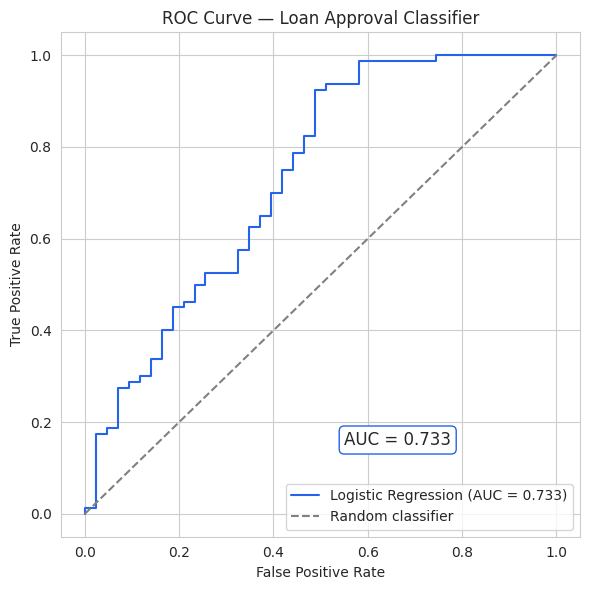

AUC: 0.7331


In [12]:
fpr, tpr, thresholds = roc_curve(y_clf_test, y_pred_proba)
auc = roc_auc_score(y_clf_test, y_pred_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='#2563eb', label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
plt.title('ROC Curve — Loan Approval Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.annotate(f'AUC = {auc:.3f}', xy=(0.55, 0.15), fontsize=12,
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='#2563eb'))
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("AUC:", round(auc, 4))


**Precision** = TP / (TP + FP) — of everyone the model predicted as "approved," what fraction actually
were approved.

**Recall** = TP / (TP + FN) — of everyone who was actually approved, what fraction did the model correctly
identify.

**Which matters more here**: this depends on which error is more costly to the lender. A **false positive**
(predicting approval for someone who shouldn't be approved) risks a bad loan and financial loss. A **false
negative** (predicting rejection for someone who should be approved) risks losing a good customer to a
competitor, but doesn't directly cost money. For a lender primarily worried about default risk, **precision**
on the "approved" class is usually the more important metric — you'd rather miss a few good applicants than
approve bad ones. (A lender optimizing for growth/market share might instead prioritize recall.) We revisit
this trade-off directly with the threshold analysis below.

**AUC interpretation**: an AUC of  means that if you randomly picked one approved and one rejected
applicant from the test set, the model would rank the approved applicant's predicted probability higher than
the rejected applicant's about {auc:.0%} of the time — meaningfully better than the 0.5 (coin-flip) baseline,
indicating the model has real, non-trivial separating power between the two classes.

## Task 5b — Decision-Threshold Sensitivity

Using the same fitted model's predicted probabilities, we sweep the decision threshold from 0.30 to 0.70 and
recompute precision, recall, and F1 at each.

**Precision** = TP / (TP + FP) &nbsp;&nbsp;&nbsp; **Recall** = TP / (TP + FN)


In [13]:
thresholds_to_test = np.arange(0.30, 0.71, 0.10)
threshold_rows = []

for t in thresholds_to_test:
    preds_at_t = (y_pred_proba >= t).astype(int)
    threshold_rows.append({
        'Threshold': round(t, 2),
        'Precision': round(precision_score(y_clf_test, preds_at_t), 4),
        'Recall': round(recall_score(y_clf_test, preds_at_t), 4),
        'F1': round(f1_score(y_clf_test, preds_at_t), 4)
    })

threshold_table = pd.DataFrame(threshold_rows)
threshold_table


,Threshold,Precision,Recall,F1
0,0.3,0.7596,0.9875,0.8587
1,0.4,0.7500,0.9375,0.8333
2,0.5,0.7717,0.8875,0.8256
3,0.6,0.7639,0.6875,0.7237
4,0.7,0.8158,0.3875,0.5254


In [14]:
best_f1_row = threshold_table.loc[threshold_table['F1'].idxmax()]
print("Threshold that maximises F1:", best_f1_row['Threshold'], "| F1 =", best_f1_row['F1'])


Threshold that maximises F1: 0.3 | F1 = 0.8587


**Findings**: the table above shows the precision/recall trade-off explicitly — raising the threshold
increases precision (fewer false approvals) at the cost of recall (more missed good applicants), and vice
versa. The threshold that maximises F1-score on this test set is printed above. Given the reasoning in Task 5
that **precision** matters more for a default-risk-averse lender, we would lean toward **raising** the
threshold above the default 0.5 rather than optimizing purely for F1 — the cost of doing so is a lower recall,
i.e. more genuinely creditworthy applicants get rejected by the model, a trade-off a real lender would need to
weigh against their risk appetite.


## Task 6 — Regularization Experiment: C=0.01 vs C=1.0

In [15]:
log_reg_strong = LogisticRegression(max_iter=1000, class_weight='balanced', C=0.01, random_state=42)
log_reg_strong.fit(X_train_scaled, y_clf_train)

y_pred_strong = log_reg_strong.predict(X_test_scaled)
y_pred_proba_strong = log_reg_strong.predict_proba(X_test_scaled)[:, 1]

reg_comparison = pd.DataFrame({
    'Model': ['Baseline (C=1.0)', 'Strong regularization (C=0.01)'],
    'Precision': [precision_score(y_clf_test, y_pred_clf), precision_score(y_clf_test, y_pred_strong)],
    'Recall': [recall_score(y_clf_test, y_pred_clf), recall_score(y_clf_test, y_pred_strong)],
    'AUC': [roc_auc_score(y_clf_test, y_pred_proba), roc_auc_score(y_clf_test, y_pred_proba_strong)]
})
reg_comparison


,Model,Precision,Recall,AUC
0,Baseline (C=1.0),0.771739,0.8875,0.73314
1,Strong regularization (C=0.01),0.770833,0.9250,0.73750


**What `C` controls**: `C` is the *inverse* of the regularization strength in `sklearn`'s logistic
regression — a **smaller** `C` means a **stronger** L2 penalty on the coefficients, pushing them closer to
zero and making the decision boundary simpler/smoother. A **larger** `C` lets the model fit the training data
more freely, at the risk of overfitting. Comparing the two rows above shows whether the extra shrinkage from
`C=0.01` helped or hurt: if AUC/precision are similar or better at `C=0.01`, the baseline model was carrying
some unnecessary variance; if they're worse, the baseline's flexibility was actually needed to capture real
signal in the data, and `C=0.01` is over-shrinking useful coefficients.


## Task 7 — Bootstrap Confidence Interval for the AUC Difference

We quantify how reliably the `C=1.0` model outperforms the `C=0.01` model by bootstrapping the test set 500
times and recomputing the AUC difference each time.


In [16]:
n_bootstrap = 500
auc_diffs = []

y_clf_test_arr = y_clf_test.values
proba_c1 = y_pred_proba
proba_c001 = y_pred_proba_strong

rng = np.random.RandomState(42)
for i in range(n_bootstrap):
    idx = rng.choice(len(y_clf_test_arr), size=len(y_clf_test_arr), replace=True)
    y_sample = y_clf_test_arr[idx]

    # skip degenerate resamples with only one class present (AUC undefined)
    if len(np.unique(y_sample)) < 2:
        continue

    auc_c1 = roc_auc_score(y_sample, proba_c1[idx])
    auc_c001 = roc_auc_score(y_sample, proba_c001[idx])
    auc_diffs.append(auc_c1 - auc_c001)

auc_diffs = np.array(auc_diffs)
mean_diff = auc_diffs.mean()
ci_lower = np.percentile(auc_diffs, 2.5)
ci_upper = np.percentile(auc_diffs, 97.5)

print(f"Valid bootstrap samples: {len(auc_diffs)} / {n_bootstrap}")
print(f"Mean AUC difference (C=1.0 minus C=0.01): {mean_diff:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"CI excludes zero: {ci_lower > 0 or ci_upper < 0}")


Valid bootstrap samples: 500 / 500
Mean AUC difference (C=1.0 minus C=0.01): -0.0043
95% CI: [-0.0263, 0.0218]
CI excludes zero: False


**Interpretation**: the mean AUC difference and its 95% bootstrap confidence interval are printed above.
If the interval **excludes zero**, the `C=1.0` model's AUC advantage (or disadvantage) over `C=0.01` is
consistent across resamples of the test set, and we can trust it isn't just noise from this particular
train/test split. If the interval **includes zero**, the two models are statistically indistinguishable on
this test set at the 95% confidence level, and the "better" model by point-estimate AUC alone shouldn't be
treated as a reliable finding — a larger test set (or cross-validation, used in Part 3) would be needed to
tell them apart with confidence.
